# Principal Diamaters, Sphericity, and Roundness Measurement - 2D

Author: [LinkedIn - Cinar Turhan](https://www.linkedin.com/in/cinarturhan/)

### Description

The `find_and_plot_principal_diameters_2D` function calculates and plots the principal diameters of a binary surface/image. This is a 2D adoptation of the 3D version of this code.

This notebook is prepared to analyze disconnected - or individual - grains that were segmented using [Segment Every Grain](https://github.com/zsylvester/segmenteverygrain) model.


### Sphericity, Roundness, and Modified Roundness

These metrics are essential for characterizing the shape of grains in 2D. They provide insights into how circular, elongated, or irregular a grain is, based on its geometry and measurements.

#### Sphericity  
Sphericity is calculated as the ratio of the two principal diameters ($ d_1 $ and $ d_2 $), where $ d_1 $ is the shorter diameter and $ d_2 $ is the longer diameter. This metric indicates how close the grain is to being circular in 2D.  

$$
\text{Sphericity} = \frac{d_1}{d_2}
$$  

A value closer to 1 suggests a more spherical shape, while smaller values indicate elongation or irregularity.

#### Roundness  
Roundness measures how closely the shape of the grain resembles a perfect circle. It is defined using the area and perimeter of the grain:  

$$
\text{Roundness} = \frac{4 \pi \cdot \text{Area}}{\text{Perimeter}^2}
$$  

A roundness value closer to 1 indicates a more circular shape, while lower values represent irregular or elongated grains.

#### Modified Roundness  
Modified roundness incorporates both sphericity and the equivalent circumference of a grain. The equivalent circumference is calculated from the equivalent diameter (a circular approximation of the grain’s area). Modified roundness refines the traditional roundness by considering how sphericity relates to the perimeter:  

$$
\text{Modified Roundness} = \text{Sphericity} \cdot \frac{\text{Equivalent Circumference}}{\text{Perimeter}}
$$  

This metric provides additional detail on how elongation and perimeter interact to influence the grain’s overall shape.

---

### How the Metrics Are Derived

- **Principal Diameters** ($ d_1, d_2 $):  
  These are found using the function `find_and_plot_principal_diameters_2D`, which computes the shortest and longest axes of the grain based on its binary representation.

- **Area**:  
  The area of the grain is extracted using the `regionprops` function from `skimage`, which computes the number of pixels within the binary mask representing the grain.

- **Perimeter**:  
  The perimeter is calculated using the grain’s binary boundary, as determined by `skimage.measure.perimeter`.

- **Equivalent Diameter and Circumference**:  
  The equivalent diameter is a measure of the diameter of a circle that has the same area as the grain. Its circumference is computed as:  

  $$
  \text{Equivalent Circumference} = \pi \cdot \text{Equivalent Diameter}
  $$

By combining these measurements, the sphericity, roundness, and modified roundness provide comprehensive shape characterizations for segmented grains.



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage
import scipy
import glob

from ipywidgets import interactive
import ipywidgets as widgets
from skimage.measure import regionprops, label
from skimage.io import imread
from skimage.exposure import rescale_intensity
from utils import find_and_plot_principal_diameters_2D
%matplotlib widget
# %matplotlib inline

Principal Diameter 1: 62
Principal Diameter 2: 62
Sphericity: 100.0 %
Roundness: 90.59 %
Modified Roundness: 95.18 %


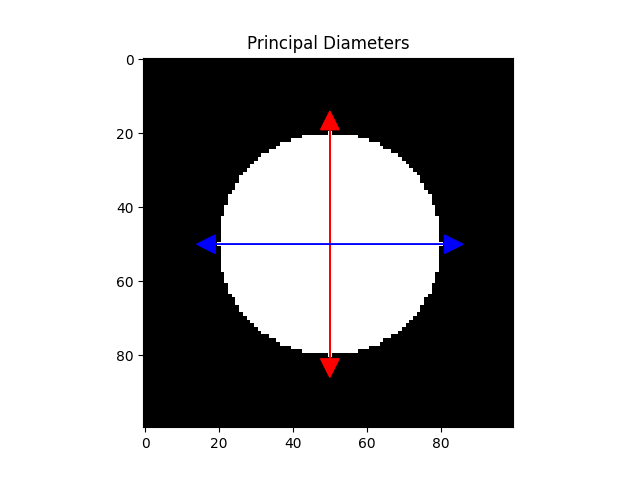

In [2]:
binary_circle = np.zeros((100, 100), dtype=int)
rr, cc = np.ogrid[:100, :100]
mask = (rr - 50)**2 + (cc - 50)**2 <= 30**2 
binary_circle[mask] = 1

d1, d2, fig, ax = find_and_plot_principal_diameters_2D(binary_circle)
sphericity = d1/d2
print(f'Sphericity: {round(sphericity*100,2)} %')

props = skimage.measure.regionprops(binary_circle.astype(int))
area = props[0].area
eq_d = props[0].equivalent_diameter_area
eq_circumference = 2*np.pi*eq_d/2
perimeter = skimage.measure.perimeter(binary_circle.astype(int))

roundness = 4*np.pi*area/(perimeter**2)

mod_roundness = sphericity*eq_circumference/perimeter
print(f'Roundness: {round(roundness*100,2)} %')
print(f'Modified Roundness: {round(mod_roundness*100,2)} %')

Principal Diameter 1: 41
Principal Diameter 2: 41
Sphericity: 100.0 %
Roundness: 82.62 %
Modified Roundness: 90.9 %


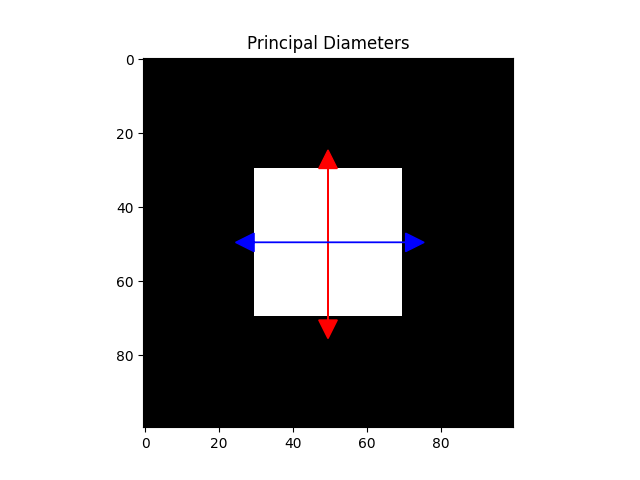

In [3]:
binary_square = np.zeros((100, 100), dtype=int)
binary_square[30:70, 30:70] = 1  
d1, d2, fig, ax = find_and_plot_principal_diameters_2D(binary_square)
sphericity = d1/d2
print(f'Sphericity: {round(sphericity*100,2)} %')

props = skimage.measure.regionprops(binary_square.astype(int))
area = props[0].area
eq_d = props[0].equivalent_diameter_area
eq_circumference = 2*np.pi*eq_d/2
perimeter = skimage.measure.perimeter(binary_square.astype(int))

roundness = 4*np.pi*area/(perimeter**2)

mod_roundness = sphericity*eq_circumference/perimeter
print(f'Roundness: {round(roundness*100,2)} %')
print(f'Modified Roundness: {round(mod_roundness*100,2)} %')


Principal Diameter 1: 42
Principal Diameter 2: 62
Sphericity: 67.74 %
Roundness: 68.35 %
Modified Roundness: 56.0 %


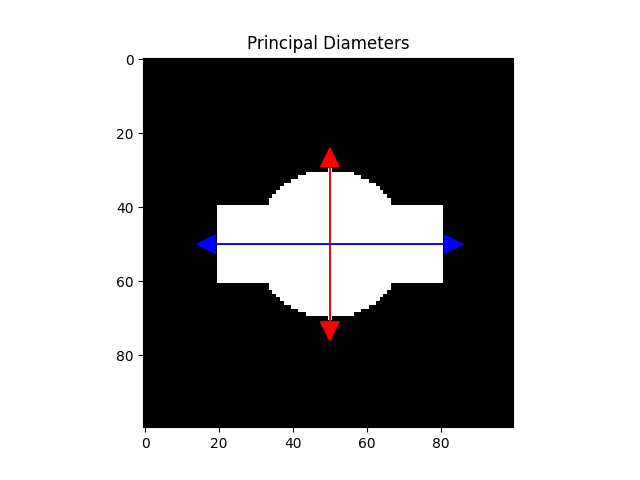

In [4]:
binary_weird_shape = np.zeros((100, 100), dtype=int)
rr, cc = np.ogrid[:100, :100]
mask1 = (rr - 50)**2 + (cc - 50)**2 <= 20**2  # circle
mask2 = (rr >= 40) & (rr <= 60) & (cc >= 20) & (cc <= 80)  # horizontal rectangle
binary_weird_shape[mask1 | mask2] = 1  # combined circle and rectangle


d1, d2, fig, ax = find_and_plot_principal_diameters_2D(binary_weird_shape)
sphericity = d1/d2
print(f'Sphericity: {round(sphericity*100,2)} %')

props = skimage.measure.regionprops(binary_weird_shape.astype(int))
area = props[0].area
eq_d = props[0].equivalent_diameter_area
eq_circumference = 2*np.pi*eq_d/2
perimeter = skimage.measure.perimeter(binary_weird_shape.astype(int))

roundness = 4*np.pi*area/(perimeter**2)

mod_roundness = sphericity*eq_circumference/perimeter
print(f'Roundness: {round(roundness*100,2)} %')
print(f'Modified Roundness: {round(mod_roundness*100,2)} %')


In [5]:
img_list = glob.glob('./grain_polygon_images/*.png')

# Reading Images
grain_list = [imread(img) for img in sorted(img_list)]
grain_list = [grain[:,:,0] for grain in grain_list]
grain_list_rescaled = [rescale_intensity(grain, out_range=(1,0)) for grain in grain_list]

grain_names = [f"Grain-{path.split('_')[3].split('.')[0]}" for path in sorted(img_list)]

Principal Diameter 1: 227
Principal Diameter 2: 365


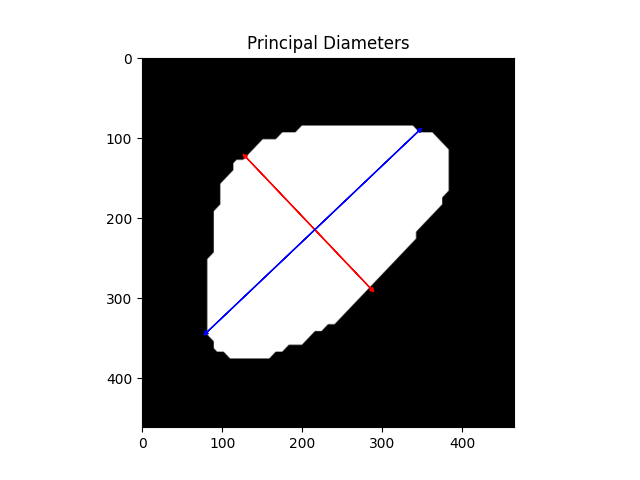

In [6]:
_ = find_and_plot_principal_diameters_2D(grain_list_rescaled[0])

In [ ]:
def show_img(sample,show_diameters):

    sample_dict = dict(zip(grain_names, grain_list_rescaled))

    if show_diameters:
        fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(4,4))
        fig.canvas.toolbar_visible = False
        fig.canvas.header_visible = False
        fig.canvas.footer_visible = False
        ax.clear()
        plt.clf()
        plt.close()
        d1, d2, fig, ax = find_and_plot_principal_diameters_2D(sample_dict[sample])
        sphericity = d1/d2
        print(f'Sphericity: {round(sphericity*100,2)} %')

        props = skimage.measure.regionprops(sample_dict[sample].astype(int))
        area = props[0].area
        eq_d = props[0].equivalent_diameter_area
        eq_circumference = 2*np.pi*eq_d/2
        perimeter = skimage.measure.perimeter(sample_dict[sample].astype(int))

        roundness = 4*np.pi*area/(perimeter**2)

        mod_roundness = sphericity*eq_circumference/perimeter
        print(f'Roundness: {round(roundness*100,2)} %')
        print(f'Modified Roundness: {round(mod_roundness*100,2)} %')
        ax.set_title(f'{sample}',fontsize=14)
        plt.show()
    else:
        fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(4,4))
        fig.canvas.toolbar_visible = False
        fig.canvas.header_visible = False
        fig.canvas.footer_visible = False
        ax.clear()
        plt.imshow(sample_dict[sample], cmap='gray')
        ax.set_title(sample,fontsize=14)
        plt.show()

shape_analysis_button = widgets.ToggleButton(
    value=False, 
    description='Shape Analysis',  
    icon='check', 
    style={'description_width': 'initial'} 
)

interactive(show_img, sample=widgets.Dropdown(options=grain_names,description='Sample: '),
            show_diameters=shape_analysis_button)


interactive(children=(Dropdown(description='Sample: ', options=('Grain-00', 'Grain-01', 'Grain-02', 'Grain-03'…

Author: [LinkedIn - Cinar Turhan](https://www.linkedin.com/in/cinarturhan/)

##### Declaration of AI usage
_This documentation has been generated with the assistance of AI tools to ensure clarity and completeness._